# PCLab#1 - Group 2 - Henricus Bracht Erdem Bayrakcioglu Leonard Fischbach

**Course:** 20598 - Finance with Big Data  
**Lab:** PC Lab #1 - Applied Portfolio Theory (Week 2)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import numpy as np
from scipy.optimize import minimize
import plotly.graph_objects as go
from plotly.subplots import make_subplots


## Task #1: Import the data and describe the sample

* Sort the stock data by date and print the number of stocks
* Check if data contains any null values
* What is the average market value of the S&P500?
* Which stock or index has the minimum dispersion in dollar value?
* What is the maximum price for Amazon stock over the specified time period?

In [2]:
stock_price_data = pd.read_csv("Data_PCLab1_Stock.csv")

# Ensure chronological order for all subsequent analyses
stock_price_data["Date"] = pd.to_datetime(stock_price_data["Date"])
stock_price_data = stock_price_data.sort_values(by="Date").reset_index(drop=True)

### CONSTANTS

In [3]:
TRADING_DAYS_PER_YEAR = 252
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

STOCK_TICKER_COLUMNS = [column_name for column_name in stock_price_data.columns if column_name not in ("Date", "sp500")]
STOCK_SP_TICKER_COLUMNS = [column_name for column_name in stock_price_data.columns if column_name not in ("Date")]

### 1.1 Load, sort by date, and count the number of stocks

In [4]:
# Exclude the date column and the S&P 500 index when counting individual stocks

number_of_stocks = len(STOCK_TICKER_COLUMNS)

print(f"Number of stocks in the sample: {number_of_stocks}")
print(f"Stock tickers: {STOCK_TICKER_COLUMNS}")
print(f"Sample period: {stock_price_data['Date'].min().date()} to {stock_price_data['Date'].max().date()}")
print(f"Number of trading days: {len(stock_price_data)}")
stock_price_data.head()

Number of stocks in the sample: 8
Stock tickers: ['AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG']
Sample period: 2012-01-12 to 2020-08-11
Number of trading days: 2159


,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


The data contains 8 stocks and 1 market index. The date column only contains trading days. Bank holidays or weekends are not included since the stock market is closed.

### 1.2 Check for missing (null) values

In [5]:
null_value_counts_by_column = stock_price_data.isnull().sum()
total_null_values = null_value_counts_by_column.sum()

print("Null values per column:")
print(null_value_counts_by_column)
print()

if total_null_values == 0:
    print("The dataset contains no null values.")
else:
    print(f"The dataset contains {total_null_values} null value(s) in total.")

Null values per column:
Date     0
AAPL     0
BA       0
T        0
MGM      0
AMZN     0
IBM      0
TSLA     0
GOOG     0
sp500    0
dtype: int64

The dataset contains no null values.


### 1.3 Average market value of the S&P 500

In [6]:
# In this dataset, "market value" refers to the S&P 500 index level (price series)
average_sp500_market_value = stock_price_data["sp500"].mean()

print(f"Average market value of the S&P 500 over the sample period: {average_sp500_market_value:.2f}")

Average market value of the S&P 500 over the sample period: 2218.75


The average market value represents the mean level of the S&P 500 index over the observed time period (2012-01-12 to 2020-08-11). An important caveat here is that this is an average index level and not an average market value in dollars or euros.

### 1.4 Stock or index with the minimum dispersion in dollar value

In [7]:
price_columns = stock_price_data.drop(columns=["Date"]).columns
dollar_value_dispersion_by_series = stock_price_data[price_columns].std()

series_with_minimum_dispersion = dollar_value_dispersion_by_series.idxmin()
minimum_dispersion_value = dollar_value_dispersion_by_series.min()

print("Dollar-value dispersion (standard deviation) by series:")
print(dollar_value_dispersion_by_series.sort_values())
print()
print(
    f"Minimum dispersion: {series_with_minimum_dispersion} "
    f"(std = {minimum_dispersion_value:.4f})"
)

Dollar-value dispersion (standard deviation) by series:
T          3.207490
MGM        6.963847
IBM       25.561938
AAPL      70.827601
BA       103.678586
TSLA     210.988003
GOOG     334.448057
sp500    537.321727
AMZN     697.838905
dtype: float64

Minimum dispersion: T (std = 3.2075)


We define dollar value dispersion as the std of the given price levels. As calculated above, T (AT&T) has the lowest dispersion.
Importantly, absolute price dispersion is scale-dependent and not comparable across stocks with different price levels. For example, a stock split lowers the share price and the dollar dispersion without changing the underlying economic risk of the firm. Hence, we cannot interpret this as risk or relative volatility. 

### 1.5 Maximum price for Amazon over the sample period

In [8]:
maximum_amazon_price = stock_price_data["AMZN"].max()
date_of_maximum_amazon_price = stock_price_data.loc[
    stock_price_data["AMZN"].idxmax(), "Date"
]

print(f"Maximum Amazon (AMZN) price over the sample period: {maximum_amazon_price:.2f}")
print(f"Date of maximum Amazon price: {date_of_maximum_amazon_price.date()}")

Maximum Amazon (AMZN) price over the sample period: 3225.00
Date of maximum Amazon price: 2020-08-06


We would like to note that this is not the ATH but only the max value in the observed period (2012-01-12 to 2020-08-11).

## Task #2 : Plot the data
* Define a function to plot the entire dataframe
  * The function takes in a dataframe as an input argument and does not return
anything back

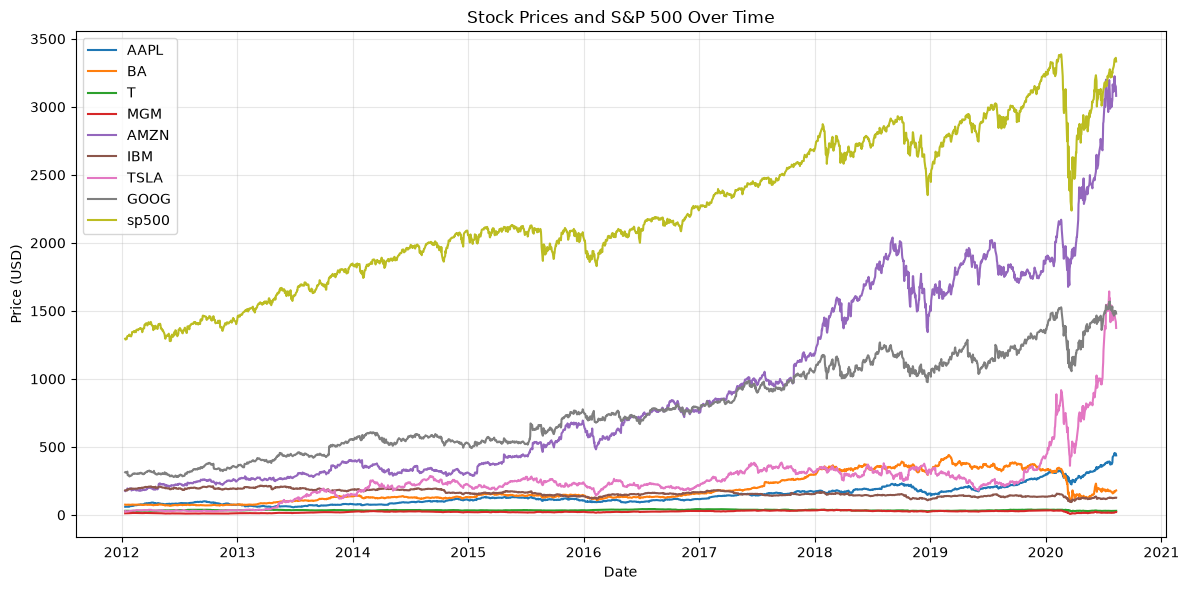

In [9]:
def plot_stock_prices(stock_prices, y_axis_label):
    figure, axes = plt.subplots(figsize=(12, 6))

    for ticker_name in STOCK_SP_TICKER_COLUMNS:
        axes.plot(
            stock_prices["Date"],
            stock_prices[ticker_name],
            label=ticker_name,
        )

    axes.set_title("Stock Prices and S&P 500 Over Time")
    axes.set_xlabel("Date")
    axes.set_ylabel(y_axis_label)
    axes.legend(loc="upper left")
    axes.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plot the full stock price sample (no return value)
plot_stock_prices(stock_price_data, "Price (USD)")


The plot shows substantial differences in prices between the 8 stocks and S&P500 index. Stocks with lower absolute prices are harder to compare visually to higher priced stocks. For example, a stock that costs 1$ and appreciates to 2$ would make 100% profit, but it would be barely visible in this chart. A stock that costs 1000$ and appreciates to 1100$ would have just made a 10% profit, yet you could clearly see it on this chart.  

As a result, comparing normalized prices would allow for a more comprehensible comparison of relative development over time.

## Task #3 : Print out normalized (scaled) stock prices
* Define a function to normalize the prices based on the initial price
  * The function simply divides every stock by it’s price at the start date (i.e. : Date = 2012-01-12)
* Plot normalized data

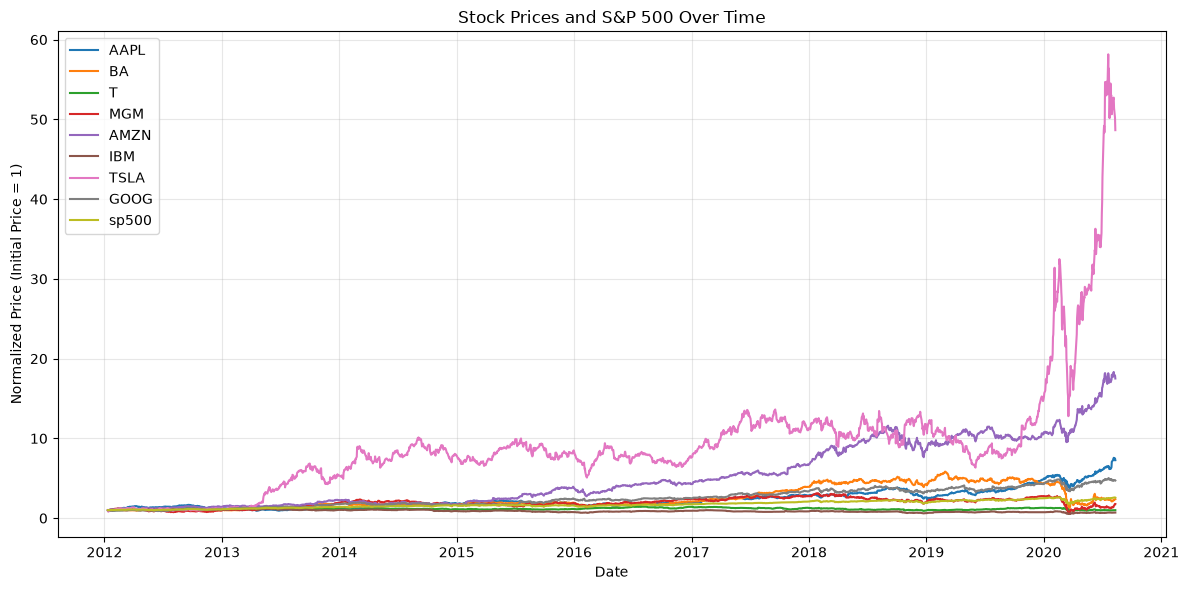

In [10]:
def normalize_stock_prices(stock_prices):
    normalized_stock_prices = stock_prices.copy()

    starting_prices = stock_prices.loc[0, STOCK_SP_TICKER_COLUMNS]

    for ticker_name in STOCK_SP_TICKER_COLUMNS:
        normalized_stock_prices[ticker_name] = (
            stock_prices[ticker_name] / starting_prices[ticker_name]
        )

    return normalized_stock_prices


normalized_stock_prices = normalize_stock_prices(stock_price_data)
plot_stock_prices(normalized_stock_prices, "Normalized Price (Initial Price = 1)")

This graph is way more insightful than the previously displayed absolute values. The graph shows substantial differences in performance between the different stocks. Tesla (Ticker: TSLA) has the strongest relative price increase followed by Amazon (Ticker: AMZN).

It is important to note that, firstly, this chart is relative to the first observation and secondly that we do not consider other investment returns like dividends.


## Task #5: Calculate stock returns
* Define a function to calculate stocks daily returns (for all stocks)
  * Loop through each stock
  * Loop through each row belonging to the stock
* Plot it!
* Calculate the correlations between daily returns
* Plot the correlation table as in heat-map
* What are the top 2 stocks that are positively correlated with the S&P500?
* What is the correlation between Amazon and Boeing? Comment on your answer
* What is the correlation between MGM and Boeing? Comment on your answer
* Plot the histograms of daily returns and comment
* Optional : Define a function to perform an interactive and fancy histograms plots using Plotly module
  * Plotly’s Python API contains a super powerful module known as figure factory

### 5.1 Calculate daily returns for all stocks and plot them

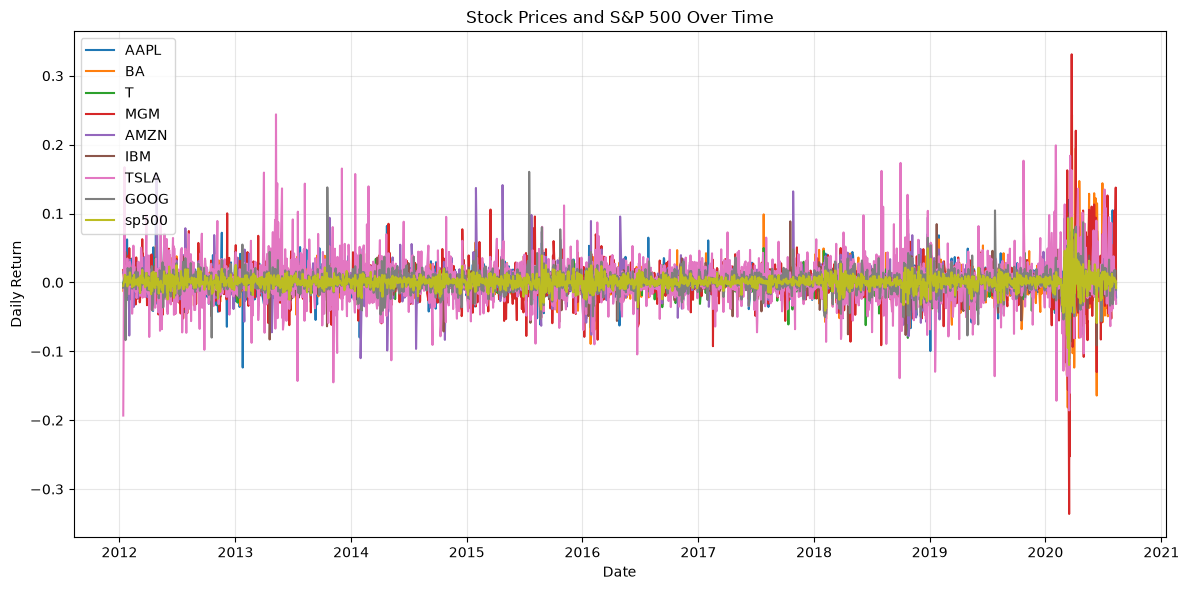

In [11]:
def calculate_daily_returns(stock_prices):
    daily_returns = stock_prices.copy()

    for ticker_name in STOCK_SP_TICKER_COLUMNS:
        for row_index in range(1, len(stock_prices)):
            previous_price = stock_prices.loc[row_index - 1, ticker_name]
            current_price = stock_prices.loc[row_index, ticker_name]
            daily_returns.loc[row_index, ticker_name] = (
                (current_price - previous_price) / previous_price
            )
    daily_returns = daily_returns.iloc[1:].reset_index(drop=True)
    return daily_returns


daily_stock_returns = calculate_daily_returns(stock_price_data)

plot_stock_prices(daily_stock_returns, "Daily Return")



Daily returns fluctuate around 0. The magnitude is varying, especially visible at the Corona shock in 2020 which shows a period of higher volatility. Also it's visibile that single stocks show more extreme movements than the S&P500 which is in line with the lecture's content.

### 5.2 Correlations between daily returns

Calculate pairwise correlations, visualize them as a heat-map, and answer the correlation questions.


In [12]:
# Exclude the Date column before computing correlations
daily_return_correlation_matrix = daily_stock_returns[STOCK_SP_TICKER_COLUMNS].corr()

print("Correlation matrix of daily returns:")
daily_return_correlation_matrix


Correlation matrix of daily returns:


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
AAPL,1.000000,0.385249,0.341373,0.384088,0.410233,0.434534,0.288534,0.509124,0.657320
BA,0.385249,1.000000,0.401602,0.554229,0.267466,0.479264,0.250946,0.388048,0.641826
T,0.341373,0.401602,1.000000,0.340166,0.233145,0.484219,0.152515,0.353695,0.617463
MGM,0.384088,0.554229,0.340166,1.000000,0.309016,0.441631,0.311879,0.439141,0.631449
AMZN,0.410233,0.267466,0.233145,0.309016,1.000000,0.339589,0.310083,0.575283,0.539560
IBM,0.434534,0.479264,0.484219,0.441631,0.339589,1.000000,0.245610,0.458816,0.703935
TSLA,0.288534,0.250946,0.152515,0.311879,0.310083,0.245610,1.000000,0.322804,0.387920
GOOG,0.509124,0.388048,0.353695,0.439141,0.575283,0.458816,0.322804,1.000000,0.684571
sp500,0.657320,0.641826,0.617463,0.631449,0.539560,0.703935,0.387920,0.684571,1.000000


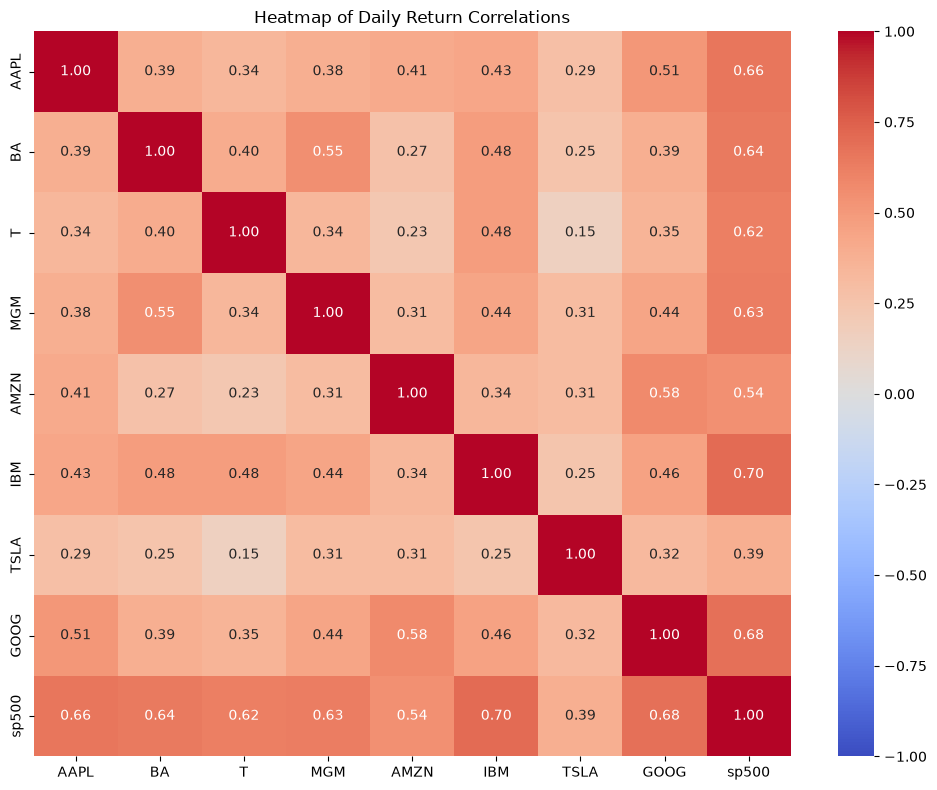

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(daily_return_correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Heatmap of Daily Return Correlations")
plt.tight_layout()
plt.show()


In [14]:
# Correlations of each stock with the S&P 500 (exclude the index itself)
correlation_with_sp500 = daily_return_correlation_matrix["sp500"].drop("sp500").sort_values(ascending=False)

print("Top 2 stocks positively correlated with the S&P 500:")
print(correlation_with_sp500.head(2))


Top 2 stocks positively correlated with the S&P 500:
IBM     0.703935
GOOG    0.684571
Name: sp500, dtype: float64


The two stocks most positively correlated with the S&P 500 are IBM (~0.70) and Google (Ticker: GOOG) (~0.68).


In [15]:
amazon_boeing_correlation = daily_return_correlation_matrix.loc["AMZN", "BA"]

print(f"Correlation between Amazon (AMZN) and Boeing (BA): {amazon_boeing_correlation}")


Correlation between Amazon (AMZN) and Boeing (BA): 0.26746551189775525


The Amazon-Boeing correlation is positive but only moderate (c. 0.27). This is most likely caused by the different industries they operate in, one is tech and the other one is aerospace / defense.


In [16]:
mgm_boeing_correlation = daily_return_correlation_matrix.loc["MGM", "BA"]

print(f"Correlation between MGM and Boeing (BA): {mgm_boeing_correlation}")


Correlation between MGM and Boeing (BA): 0.5542293135840756


The MGM-Boeing correlation is higher (c. 0.55). This makes sense as MGM is travel and entertainment industry while Boeing is doing aerospace. The common component is travel. During the Covid-19 pandemic that is within the considered time frame, the travel industry suffered.


### 5.3 Histograms of daily returns

Plot the distribution of daily returns for each series and comment on the shapes.


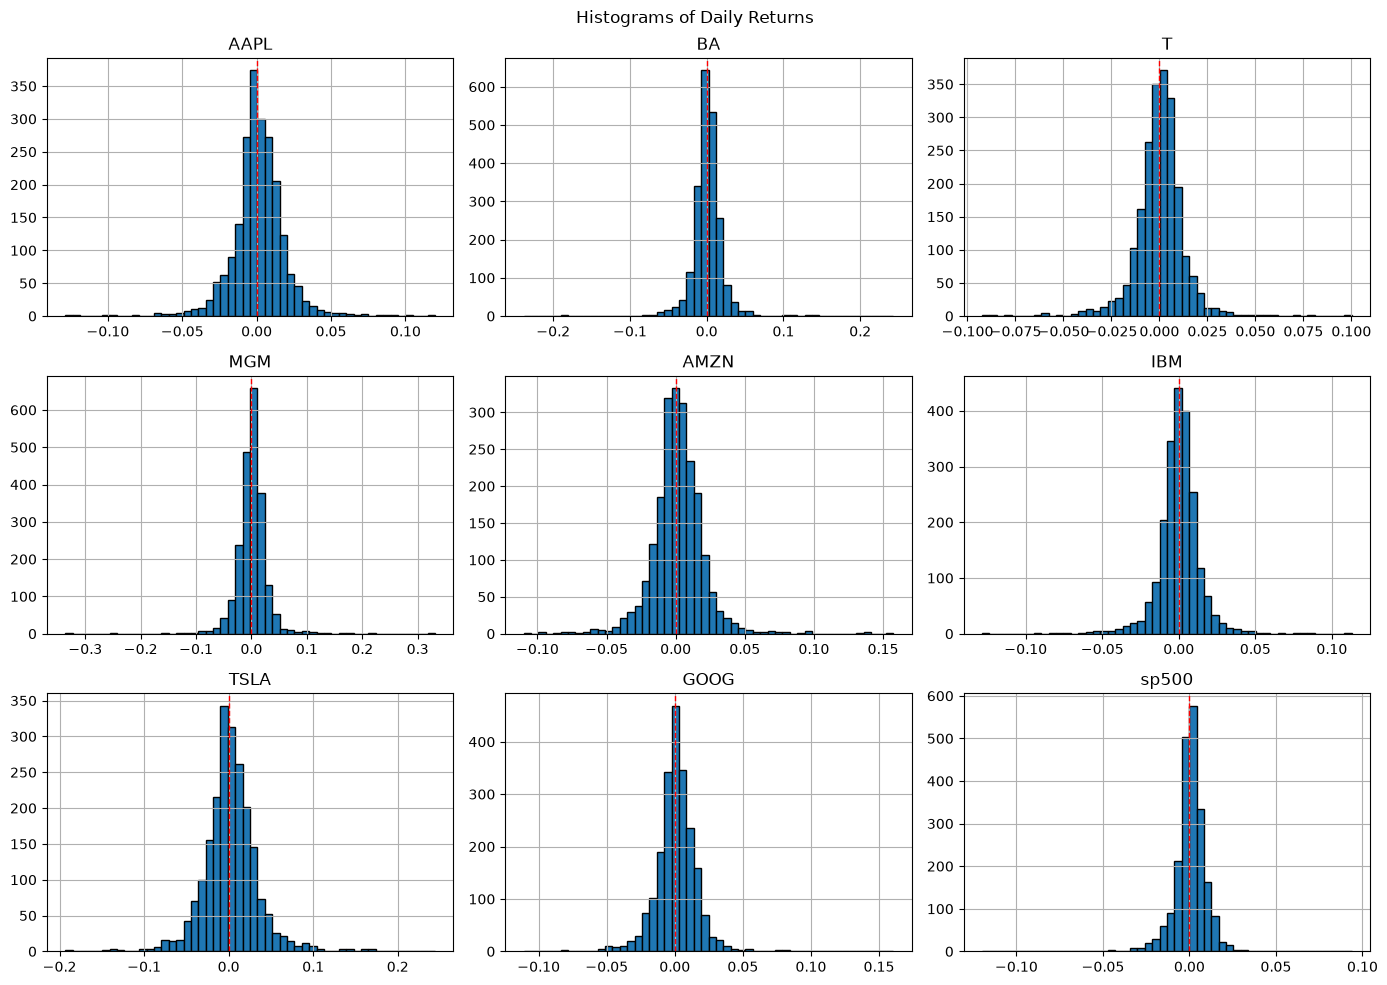

In [17]:
axes = daily_stock_returns.drop(columns=["Date"]).hist(bins=50, figsize=(14, 10), edgecolor="black")

for axis in axes.flatten():
    axis.axvline(0, color="red", linestyle="--", linewidth=1)

plt.suptitle("Histograms of Daily Returns")
plt.tight_layout()
plt.show()


Most daily-return histograms are roughly bell-shaped and centered near zero, which is typical for daily stock returns. Compared with the S&P 500, individual stocks (especially TSLA and MGM) show larger tails: more extreme positive and negative days. That means higher day-to-day risk / volatility than the market index.


### 5.3 Optional: Interactive histograms with Plotly


In [18]:
def plot_interactive_daily_return_histograms(daily_returns):
    interactive_histogram_figure = go.Figure()

    for ticker_name in STOCK_TICKER_COLUMNS:
        interactive_histogram_figure.add_trace(go.Histogram(x=daily_returns[ticker_name].dropna(), name=ticker_name, opacity=0.55, nbinsx=80))
   

    interactive_histogram_figure.update_layout(title="Interactive Histograms of Daily Returns", xaxis_title="Daily Return", yaxis_title="Frequency", barmode="overlay", legend_title_text="Ticker", height=600, width=1000)
    interactive_histogram_figure.show()


plot_interactive_daily_return_histograms(daily_stock_returns)


## Task #6 : Portfolio weights

* Write a function that will :
  * Simulate 10,000 portfolios with random weights
  * Compute the return, the variance and the Sharpe ratio of each portfolio
  * Return the maximum Sharpe ratio and its weights
* What are the weights of your tangency portfolio? What would have been the
performance of this portfolio over the sample period? Plot it!
* Optional : Define a function that finds the weights that minimize the variance for
all possible level or return (i.e., that draw the efficient frontier). Plot it against
the previous scatter plot

### 6.1 Simulate 10,000 random portfolios and find the tangency portfolio

We use the eight individual stocks (excluding the S&P 500). Daily mean returns and the covariance matrix are annualized with 252 trading days. The risk-free rate is set to 0, so the Sharpe ratio equals excess return over volatility.


In [19]:
def simulate_random_portfolios(daily_returns, number_of_portfolios=10_000):
    # Drop non-stock columns from the returns data frame
    stock_returns = daily_returns.drop(columns=["Date", "sp500"])

    # Calculate mean returns and covariance matrix for the stock returns
    mean_returns = stock_returns.mean()
    covariance_matrix = stock_returns.cov()

    # Create an empty list to store each of the 10000 portfolio results
    portfolio_results = []

    # Create a loop to simulate different weights 10000 times
    for _ in range(number_of_portfolios):
        # Randomly generate weights as a vector of the length/amount of the number of stocks
        weights = np.random.random(len(stock_returns.columns))
        # Normalize the weights so they sum to 1
        weights = weights / weights.sum()
        # Calculate the portfolio return
        portfolio_return = weights @ mean_returns
        # Calculate the portfolio variance
        portfolio_variance = np.dot(weights, np.dot(covariance_matrix.values, weights))
   
        # Volatility as the standard deviation (square root of variance)      
        portfolio_volatility = np.sqrt(portfolio_variance)
        
        sharpe_ratio = portfolio_return / portfolio_volatility

        # Append to our initially created list above
        portfolio_results.append(
            {
                "return": portfolio_return,
                "variance": portfolio_variance,
                "volatility": portfolio_volatility,
                "sharpe_ratio": sharpe_ratio,
                "weights": weights,
            }

        )

    #Convert the list where we stored all our results in from the simulations to a dataframe for easier manipulation and data retrieval
    simulated_portfolios = pd.DataFrame(portfolio_results)

    # Find the portfolio with the highest Sharpe ratio
    best_portfolio = simulated_portfolios.loc[simulated_portfolios["sharpe_ratio"].idxmax()]

    # Retrieve the weights of the best portfolio
    tangency_weights = pd.Series(best_portfolio["weights"], index=stock_returns.columns)

    # Return the maximum sharpe ratio, the weights and our simulation results dataframe
    return best_portfolio["sharpe_ratio"], tangency_weights, simulated_portfolios


# Call the function...
maximum_sharpe_ratio, tangency_portfolio_weights, simulated_portfolios = simulate_random_portfolios(daily_stock_returns)

#... and print the main findings
print(f"Maximum Sharpe ratio: {maximum_sharpe_ratio*np.sqrt(TRADING_DAYS_PER_YEAR)}")
print()
print("Tangency portfolio weights:")
print(tangency_portfolio_weights)


Maximum Sharpe ratio: 1.4207904795396926

Tangency portfolio weights:
AAPL    0.267065
BA      0.014825
T       0.041057
MGM     0.024807
AMZN    0.253810
IBM     0.003193
TSLA    0.259393
GOOG    0.135850
dtype: float64


Across all the 10,000 randomly simulated portfolios, the portfolio with the highest annualized Sharpe ratio achieves a value of c. 1.42. The portfolio is mainly allocated to AAPL (26.7%), TSLA (25.9%), AMZN (25.4%), and GOOG (13.6%) while the remaining stocks receive relatively small weights.

### 6.2 Tangency portfolio performance over the sample period


Tangency portfolio weights:
AAPL    0.267065
BA      0.014825
T       0.041057
MGM     0.024807
AMZN    0.253810
IBM     0.003193
TSLA    0.259393
GOOG    0.135850
dtype: float64
Tangency portfolio total return over the sample: 1569.418419664579%
S&P 500 total return over the sample: 157.3284400617513%
Maximum Sharpe ratio (annualized, rf = 0): 1.4207904795396926


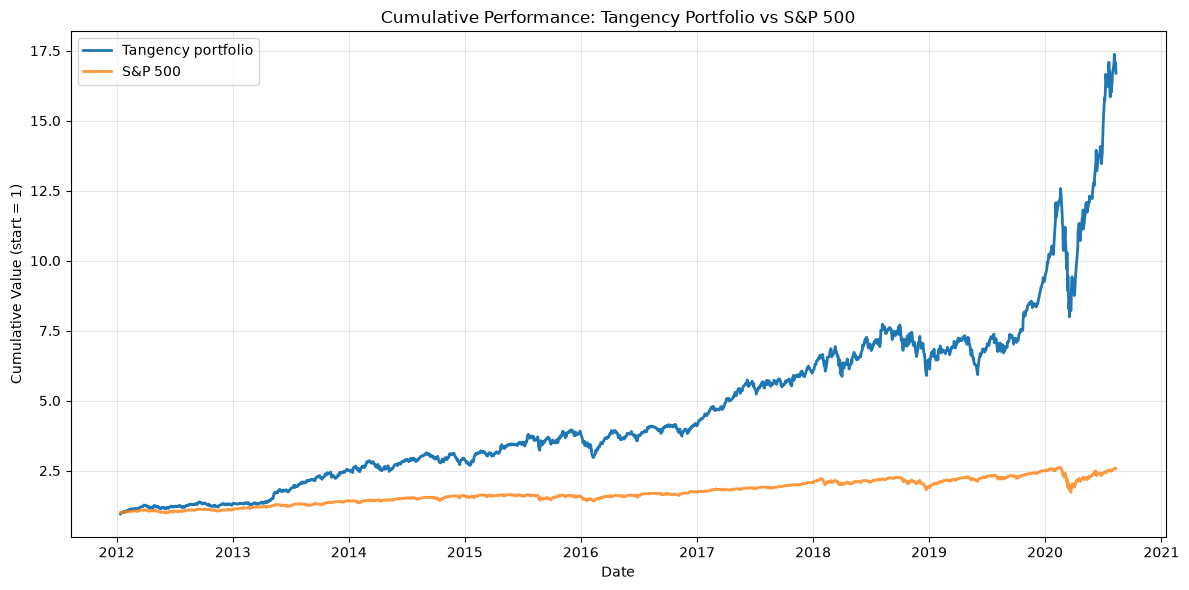

In [20]:
# Daily portfolio return is calculated as weighted sum of stock returns on each day
stock_ticker_names = tangency_portfolio_weights.index.tolist()
tangency_portfolio_daily_returns = np.dot(daily_stock_returns[stock_ticker_names], tangency_portfolio_weights)


# Cumulative performance is indexed starting at 1.0 and cumprod is a function to calculate the performance at time t as in [a, b, c]  -> [a,  a*b,  a*b*c]
tangency_portfolio_cumulative_performance = (1.0 + tangency_portfolio_daily_returns).cumprod()

# Same calculation as above for the S&P500
sp500_cumulative_performance = (1.0 + daily_stock_returns["sp500"]).cumprod()

# Calculate the performance by subtracting the last value with 1 as we indexed with starting from 1, do that for both the tangency portfolio and S&P
tangency_portfolio_total_return = tangency_portfolio_cumulative_performance[-1] - 1.0
sp500_total_return = sp500_cumulative_performance.iloc[-1] - 1.0

# print weights and performance
print("Tangency portfolio weights:")
print(tangency_portfolio_weights)
print(f"Tangency portfolio total return over the sample: {tangency_portfolio_total_return*100}%")
print(f"S&P 500 total return over the sample: {sp500_total_return*100}%")
print(f"Maximum Sharpe ratio (annualized, rf = 0): {maximum_sharpe_ratio*np.sqrt(TRADING_DAYS_PER_YEAR)}")

#Plot the cumulative performance of the tangecy portfolio against the S&P500
figure, axes = plt.subplots(figsize=(12, 6))
axes.plot(daily_stock_returns["Date"], tangency_portfolio_cumulative_performance, label="Tangency portfolio", linewidth=2)
axes.plot(daily_stock_returns["Date"], sp500_cumulative_performance, label="S&P 500", linewidth=2, alpha=0.8)
axes.set_title("Cumulative Performance: Tangency Portfolio vs S&P 500")
axes.set_xlabel("Date")
axes.set_ylabel("Cumulative Value (start = 1)")
axes.legend(loc="upper left")
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Over the entire sample period, the tangency portfolio reaches a cumulative return of c. 1569%, which is clearly outperforming the S&P500. As mentioned before, it is heavily weighted on AMZN, TSLA, GOOG and AAPL that performed very well in that period. The comparison to the S&P500 has a caveat: We use in-sample information, hence we have a lookahead bias. We use information that we did not have during the sample period, therefore we cannot compare the tangency portfolio as a suitable investment strategy to the S&P500.

### 6.3 Scatter plot of simulated portfolios (risk-return space)


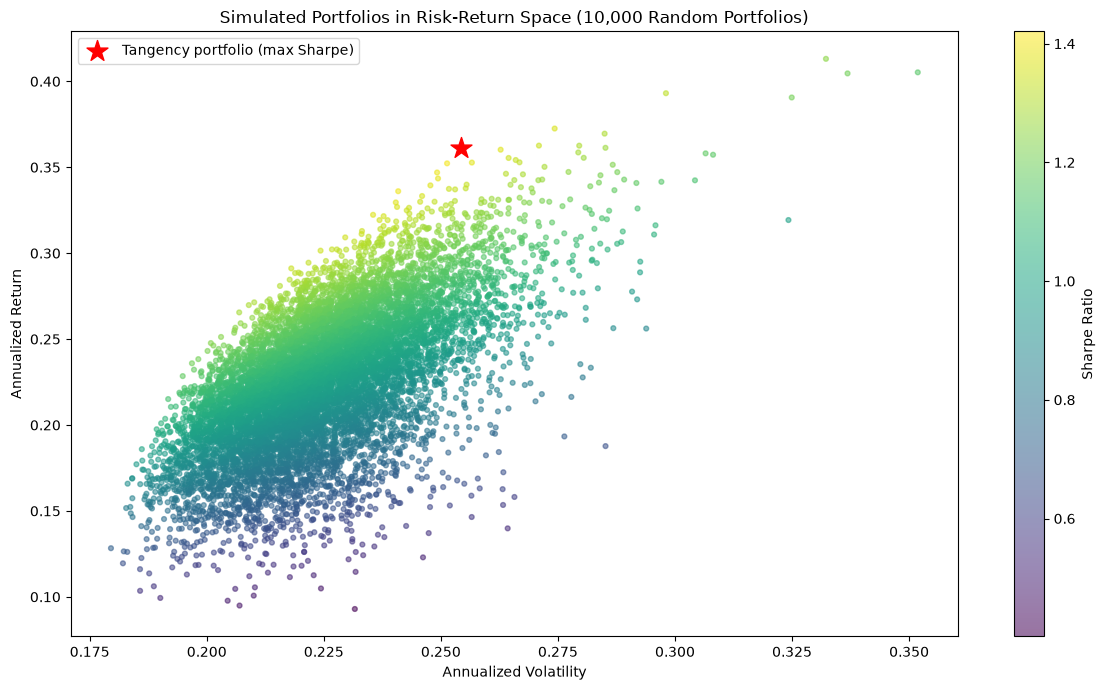

In [21]:
figure, axes = plt.subplots(figsize=(12, 7))

# Calculate the annualized return and volatility
annualized_returns = simulated_portfolios["return"] * TRADING_DAYS_PER_YEAR
annualized_volatilities = simulated_portfolios["volatility"] * np.sqrt(TRADING_DAYS_PER_YEAR)

scatter = axes.scatter(annualized_volatilities, annualized_returns, c=(simulated_portfolios["sharpe_ratio"]*np.sqrt(TRADING_DAYS_PER_YEAR)), cmap="viridis", alpha=0.55, s=12)

# Find the portfolio with the highest Sharpe ratio
best_portfolio = simulated_portfolios.loc[simulated_portfolios["sharpe_ratio"].idxmax()]

# Highlight the tangency portfolio
axes.scatter(best_portfolio["volatility"]* np.sqrt(TRADING_DAYS_PER_YEAR), best_portfolio["return"]* TRADING_DAYS_PER_YEAR, color="red", marker="*", s=250, label="Tangency portfolio (max Sharpe)")

axes.set_title("Simulated Portfolios in Risk-Return Space (10,000 Random Portfolios)")
axes.set_xlabel("Annualized Volatility")
axes.set_ylabel("Annualized Return")
axes.legend()
figure.colorbar(scatter, ax=axes, label="Sharpe Ratio")
plt.tight_layout()
plt.show()

This graph displays 10,000 randomly generated portfolios and the tradeoff between risk (volatility) and return. It is empirically recognizable that there is a shape of an efficient frontier that we saw during the lectures. In the next subtask, we will obtain the efficient frontier analytically.

### 6.4 Optional: Analytical efficient frontier (minimum variance for each target return)


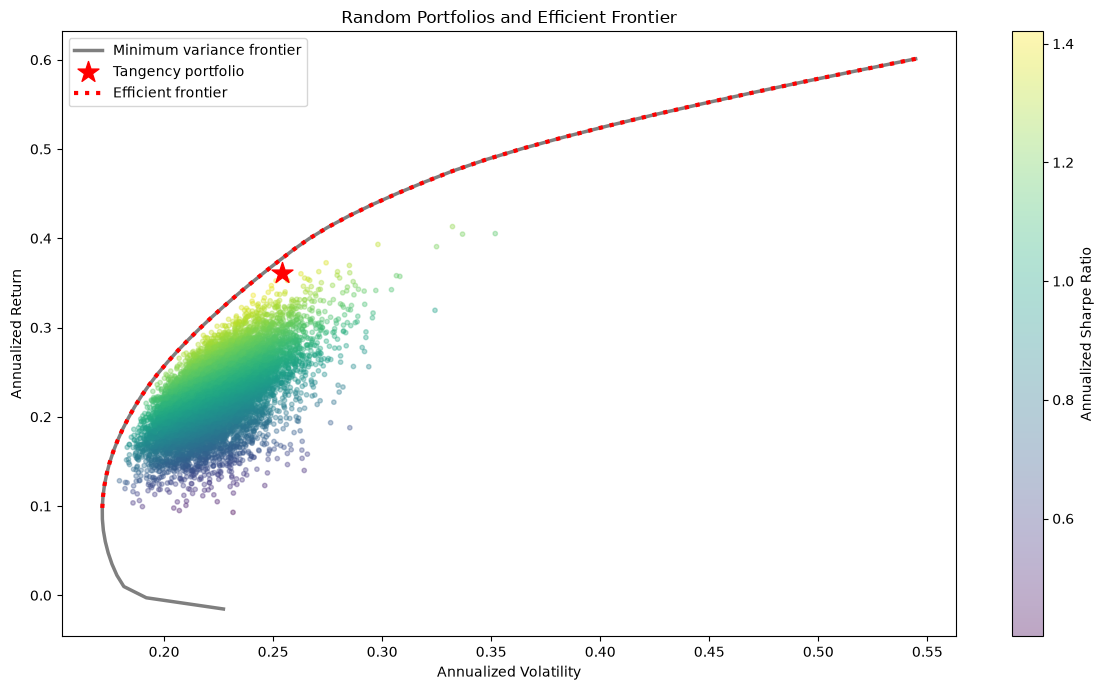

In [22]:
def compute_efficient_frontier(daily_returns, number_of_points=50):
    # Filter for stocks
    stock_returns = daily_returns.drop(columns=["Date", "sp500"])

    # Annualize the mean returns and covariance matrix
    annual_returns = stock_returns.mean() * TRADING_DAYS_PER_YEAR
    annual_covariance = stock_returns.cov() * TRADING_DAYS_PER_YEAR

    number_of_stocks = len(stock_returns.columns)

    # Create a grid of target returns to calculate the lowest possible volatility for each target return
    target_returns = np.linspace(
        annual_returns.min(),
        annual_returns.max(),
        number_of_points
    )

    # Initializing weights that are ought to be optimized at 1/8 (equally weighted)
    starting_weights = np.ones(number_of_stocks) / number_of_stocks
    # Bounding the weights between 0 and 1
    bounds = [(0, 1)] * number_of_stocks

    frontier_volatilities = []
    frontier_returns = []

    for target_return in target_returns:

        # Constraints: Sum of weights =1 and target return must be achieved as discussed in the lecture on the slide between 59 and 60 (interestingly it's lacking a page number and doesnt seem to be counted)
        constraints = [
            {
                "type": "eq",
                "fun": lambda weights: weights.sum() - 1
            },
            {
                "type": "eq",
                "fun": lambda weights, target=target_return: weights @ annual_returns - target
            }
        ]
        # minimization algorithm from scipy (documentation https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
        result = minimize(
            fun=lambda weights: weights @ annual_covariance.values @ weights, # the function to be minimized but in matrix notation also from the same slide as the constraints
            x0=starting_weights,
            bounds=bounds,
            constraints=constraints,
            method="SLSQP"
        )

        if result.success:
            portfolio_volatility = np.sqrt(result.fun)

            frontier_volatilities.append(portfolio_volatility)
            frontier_returns.append(target_return)

    return frontier_volatilities, frontier_returns

# Call the function
frontier_volatilities, frontier_returns = compute_efficient_frontier(daily_stock_returns)

#plot 
annualized_volatilities = simulated_portfolios["volatility"] * np.sqrt(TRADING_DAYS_PER_YEAR)

annualized_returns = simulated_portfolios["return"] * TRADING_DAYS_PER_YEAR

annualized_sharpe_ratios = simulated_portfolios["sharpe_ratio"] * np.sqrt(TRADING_DAYS_PER_YEAR)

figure, axes = plt.subplots(figsize=(12, 7))

scatter = axes.scatter(annualized_volatilities, annualized_returns, c=annualized_sharpe_ratios, cmap="viridis", alpha=0.35, s=10)
#efficient frontier
axes.plot(frontier_volatilities, frontier_returns, color="black", linewidth=2.5, alpha=0.5, label="Minimum variance frontier")
# highlight tangency portfolio
axes.scatter(tangency_portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR), tangency_portfolio_daily_returns.mean() * TRADING_DAYS_PER_YEAR, color="red", marker="*", s=250, label="Tangency portfolio")

# PLot the efficient frontier which is a subset of the minimum variance frontier
frontier_volatilities = np.array(frontier_volatilities)
frontier_returns = np.array(frontier_returns)

# get the minimum variance possible
minimum_variance_index = frontier_volatilities.argmin()

# Cut off the lower tail of the minimum variance frontier to get the efficient frontier
efficient_volatilities = frontier_volatilities[minimum_variance_index:]
efficient_returns = frontier_returns[minimum_variance_index:]

# Efficent part of the minimum variance frontier
axes.plot(efficient_volatilities, efficient_returns, color="red", linestyle=":", linewidth=3, label="Efficient frontier")

axes.set_title("Random Portfolios and Efficient Frontier")
axes.set_xlabel("Annualized Volatility")
axes.set_ylabel("Annualized Return")

axes.legend()
figure.colorbar(scatter, ax=axes, label="Annualized Sharpe Ratio")

plt.tight_layout()
plt.show()

For each target return i.e., in this case for the returns between minimum and maximum observed, we minimize the possible volatility as much as possible with an optimization algorithm. As a result we get the minimum variance frontier, part of which is the efficient frontier. We can see that the tangency is very close to the efficient frontier indicating that our empirical simulation does approximate the analytical optimum.

## Task #7 : Testing Portfolio Theory
* Re-run Task #6 but only on the first part of the sample (2012-2016)
* Find out what are the optimal weights for this period
* Simulate your optimal portfolio on the second part of the sample (2016-end)
  * How does it perform?
  * Plot the expected (measured over the 1st period) vs. the realized return and
volatility (over the second).
* Optional : Let’s go a step further. Every year, you re-balance your portfolio based
on last year data (ie., you create a new Markowitz portfolio every year). What is
your performance overall? Comment.

### 7.1 Re-run the tangency portfolio on 2012-2015 (in-sample)

We split the sample at 2016: estimate the max-Sharpe weights on the first period, then hold them fixed on 2016-end.


In [23]:
# Define split date
split_date = pd.Timestamp("2016-01-01")

# Split the data into in-sample and out-of-sample periods
in_sample_returns = daily_stock_returns[daily_stock_returns["Date"] < split_date].reset_index(drop=True)
out_of_sample_returns = daily_stock_returns[daily_stock_returns["Date"] >= split_date].reset_index(drop=True)

print("In-sample period:", in_sample_returns["Date"].min().date(), "to", in_sample_returns["Date"].max().date())
print("Out-of-sample period:", out_of_sample_returns["Date"].min().date(), "to", out_of_sample_returns["Date"].max().date())

# Same simulation as Task 6, but only on the first period
in_sample_sharpe, in_sample_weights, in_sample_portfolios = simulate_random_portfolios(in_sample_returns)

print(f"In-sample max Sharpe (annualized): {in_sample_sharpe * np.sqrt(TRADING_DAYS_PER_YEAR)}")

print("Optimal weights estimated on 2012-2015:")
print(in_sample_weights)


In-sample period: 2012-01-13 to 2015-12-31
Out-of-sample period: 2016-01-04 to 2020-08-11
In-sample max Sharpe (annualized): 1.6461351112966904
Optimal weights estimated on 2012-2015:
AAPL    0.072758
BA      0.129099
T       0.036954
MGM     0.043124
AMZN    0.209149
IBM     0.003748
TSLA    0.228495
GOOG    0.276673
dtype: float64


When we restrict the in sample period to 2012-2015, the results in the weights for the tangency portfolio change. While Amazon and Tesla remain the biggest positions, Apple loses a lot of share and Google and Boeing increase in share. The sharpe ratio for the in-sample period increases actually to c. 1.65. However, this is irrelevant for out-sample performance.

### 7.2 Apply the 2012-2015 weights on 2016-end

Out-of-sample tangency portfolio total return: 234.72%
Out-of-sample tangency portfolio annualized volatility: 27.13%
Out-of-sample S&P 500 total return: 63.1%
Out-of-sample S&P 500 annualized volatility: 19.37%


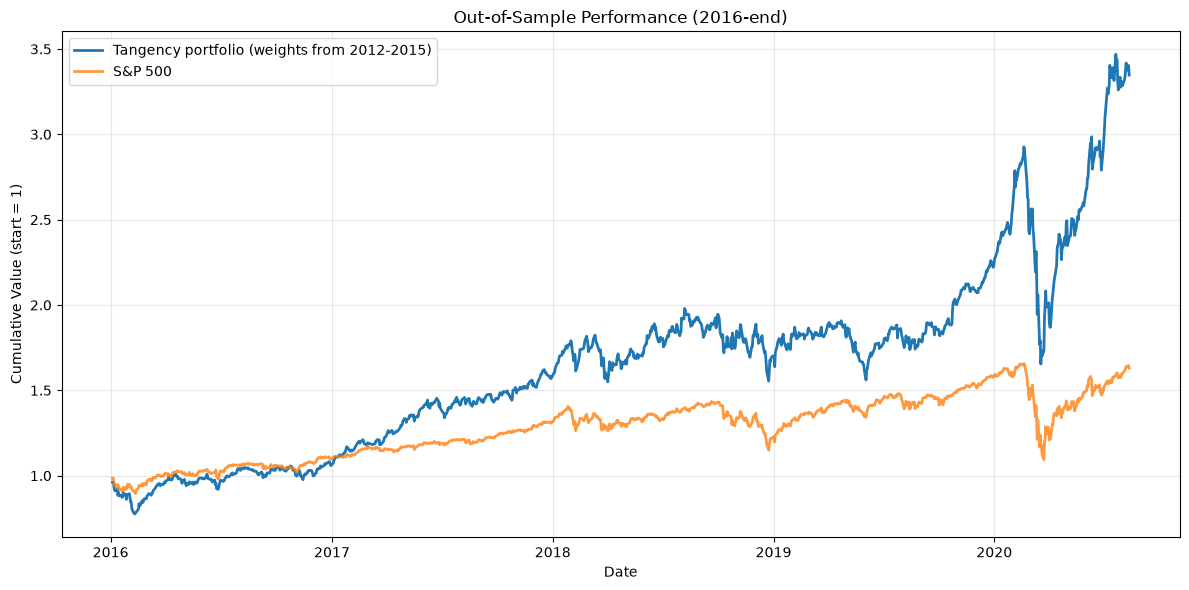

In [24]:
stock_names = in_sample_weights.index.tolist()

oos_portfolio_returns = np.dot(out_of_sample_returns[stock_names], in_sample_weights)
oos_cumulative = (1.0 + oos_portfolio_returns).cumprod()
sp500_oos_cumulative = (1.0 + out_of_sample_returns["sp500"]).cumprod()

oos_total_return = oos_cumulative[-1] - 1.0
sp500_oos_total_return = sp500_oos_cumulative.iloc[-1] - 1.0

# Calculate annualized volatility of the tangency portfolio in out-of-sample period
oos_portfolio_volatility = oos_portfolio_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
# Calculate annualized volatility of the S&P 500 in out-of-sample period
sp500_oos_volatility = out_of_sample_returns["sp500"].std() * np.sqrt(TRADING_DAYS_PER_YEAR)

print(f"Out-of-sample tangency portfolio total return: {round(oos_total_return*100,2)}%")
print(f"Out-of-sample tangency portfolio annualized volatility: {oos_portfolio_volatility:.2%}")
print(f"Out-of-sample S&P 500 total return: {round(sp500_oos_total_return*100,2)}%")
print(f"Out-of-sample S&P 500 annualized volatility: {sp500_oos_volatility:.2%}")

figure, axes = plt.subplots(figsize=(12, 6))
axes.plot(out_of_sample_returns["Date"], oos_cumulative, label="Tangency portfolio (weights from 2012-2015)", linewidth=2)
axes.plot(out_of_sample_returns["Date"], sp500_oos_cumulative, label="S&P 500", linewidth=2, alpha=0.8)

axes.set_title("Out-of-Sample Performance (2016-end)")
axes.set_xlabel("Date")
axes.set_ylabel("Cumulative Value (start = 1)")
axes.legend(loc="upper left")
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


When we use the tangency portfolio weights of the previous period, we can see that it is yielding a far higher return (c. 234.72%) comapred to the S&P500 (c. 63.1%). This result now is more meaningful than the result we had in task 6 because we eliminated the lookahead bias by evaluating the strategy on out-of-sample data. It is still important to point out that this result is specific to the observed out-of-sample period and there is no guarantee that this will work in the future.
Also, regarding volatility, the tangency portfolio of 2012-2015 is worse, which is visible in the Corona shock in 2020. 

### 7.3 Expected (in-sample) vs realized (out-of-sample) return and volatility


Expected (2012-2015) vs realized (2016-end), annualized:
  Return: expected 35.4% vs. realized 29.97%
  Volatility: expected 21.51% vs. realized 27.13%


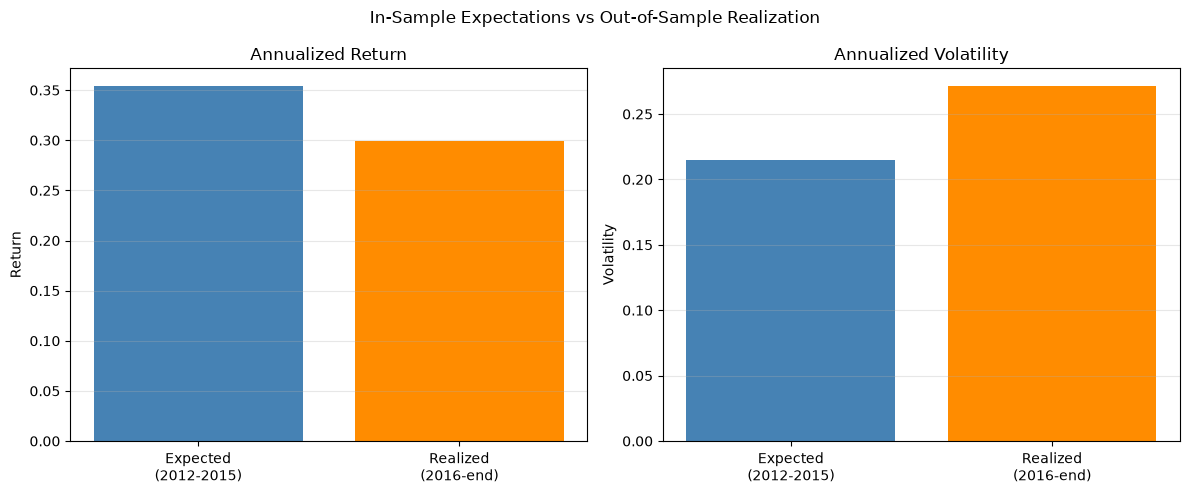

In [25]:
# Expected return / vol from the estimation period (with the chosen weights)
in_sample_stock_returns = in_sample_returns[stock_names]
in_sample_mean = in_sample_stock_returns.mean()
in_sample_cov = in_sample_stock_returns.cov()

expected_daily_return = in_sample_weights @ in_sample_mean
expected_daily_vol = np.sqrt(np.dot(in_sample_weights, np.dot(in_sample_cov.values, in_sample_weights)))

expected_annual_return = expected_daily_return * TRADING_DAYS_PER_YEAR
expected_annual_vol = expected_daily_vol * np.sqrt(TRADING_DAYS_PER_YEAR)

# Realized return / vol on the test period
realized_annual_return = oos_portfolio_returns.mean() * TRADING_DAYS_PER_YEAR
realized_annual_vol = oos_portfolio_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

print("Expected (2012-2015) vs realized (2016-end), annualized:")
print(f"  Return: expected {round(expected_annual_return*100,2)}% vs. realized {round(realized_annual_return*100,2)}%")
print(f"  Volatility: expected {round(expected_annual_vol*100,2)}% vs. realized {round(realized_annual_vol*100,2)}%")

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["Expected\n(2012-2015)", "Realized\n(2016-end)"], [expected_annual_return, realized_annual_return], color=["steelblue", "darkorange"])
axes[0].set_title("Annualized Return")
axes[0].set_ylabel("Return")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(["Expected\n(2012-2015)", "Realized\n(2016-end)"], [expected_annual_vol, realized_annual_vol], color=["steelblue", "darkorange"])
axes[1].set_title("Annualized Volatility")
axes[1].set_ylabel("Volatility")
axes[1].grid(True, axis="y", alpha=0.3)

figure.suptitle("In-Sample Expectations vs Out-of-Sample Realization")
plt.tight_layout()
plt.show()


Compared to the original period (2012-2015), the tangency portfolio produced in the out of sample period worse results both in the return and volatility dimension. This demonstrate that expectations based on historical data do not guarantee the same performance in the future. Nevertheless, the tangency portfolio outperformed the S&P500.

### 7.4 Optional: Yearly rebalancing

Strategy total return: 146.56%
S&P 500 total return: 133.75%
Strategy annualized volatility: 21.61%
S&P 500 annualized volatility: 17.08%


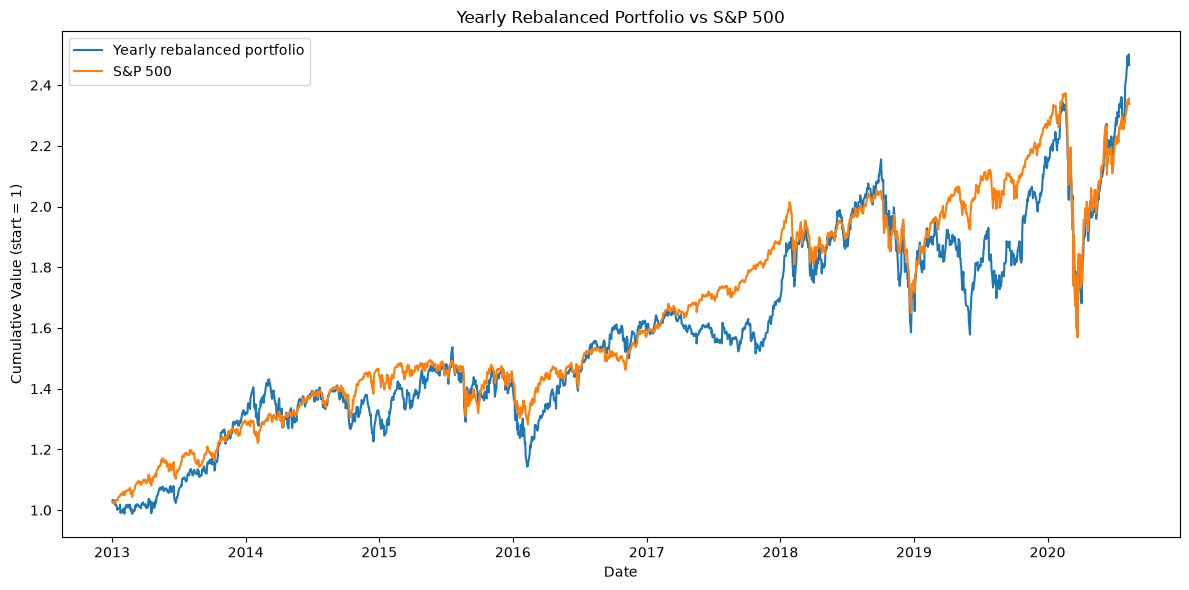

In [26]:
# Isolate the years from the data to make it possible to iterate year by year
years = sorted(daily_stock_returns["Date"].dt.year.unique())
yearly_results = []

for i in range(1, len(years)):
    # Estimation year is t-1 and evaluation year is t
    estimation_year = years[i - 1] 
    trading_year = years[i]
    # Filter for estimation and trading year
    estimation_data = daily_stock_returns[daily_stock_returns["Date"].dt.year == estimation_year]
    trading_data = daily_stock_returns[daily_stock_returns["Date"].dt.year == trading_year]
    
    # Simulate the weights for the estimation year
    _, weights, _ = simulate_random_portfolios(estimation_data)
    # Calculate the portfolio returns for the trading year
    portfolio_returns = trading_data[weights.index] @ weights
    # Append the results to the yearly_results list
    yearly_results.append(pd.DataFrame({"Date": trading_data["Date"], "portfolio_return": portfolio_returns, "sp500_return": trading_data["sp500"]}))

rebalanced_backtest = pd.concat(yearly_results)
# Calculate the performance for each date
portfolio_cumulative = (1 + rebalanced_backtest["portfolio_return"]).cumprod()
sp500_cumulative = (1 + rebalanced_backtest["sp500_return"]).cumprod()

# Print the total return for the strategy and the S&P 500
print(f"Strategy total return: {round((portfolio_cumulative.iloc[-1] - 1)*100,2)}%")
print(f"S&P 500 total return: {round((sp500_cumulative.iloc[-1] - 1)*100,2)}%")
# Calculate volatility (standard deviation of returns) annualized for portfolio and S&P 500
portfolio_vol = rebalanced_backtest["portfolio_return"].std() * (TRADING_DAYS_PER_YEAR ** 0.5)
sp500_vol = rebalanced_backtest["sp500_return"].std() * (TRADING_DAYS_PER_YEAR ** 0.5)

print(f"Strategy annualized volatility: {portfolio_vol:.2%}")
print(f"S&P 500 annualized volatility: {sp500_vol:.2%}")

figure, axes = plt.subplots(figsize=(12, 6))

axes.plot(rebalanced_backtest["Date"], portfolio_cumulative, label="Yearly rebalanced portfolio")
axes.plot(rebalanced_backtest["Date"], sp500_cumulative, label="S&P 500")

axes.set_title("Yearly Rebalanced Portfolio vs S&P 500")
axes.set_xlabel("Date")
axes.set_ylabel("Cumulative Value (start = 1)")
axes.legend()

plt.tight_layout()
plt.show()

The yearly rebalanced portfolio uses information from the prior year to estimate the weights for the current year. Over the backtest period, we see an outperformance in returns of our strategy with a total return of c. 146.56% vs. the S&P500 with 133.75%. Yet, the yearly reweighting strategy has a higher volatility.